**Objective
:**
Developing a movie recommendation system using decision tree

**Import the following libraries:**


*   numpy (as np)
*   pandas(as pd)
*   sklearn
*   nltk



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import sklearn as tree

**About the dataset**

In the dataset we have many labels like user id , movie id,movie title, genre, language,release year,duration_min,director,user review,rating,sentiment,watch_time_min and recommendation part of ouer job is to build a model to find out the recommandation of movies

now read the data using the pandas dataframe

In [ ]:
my_data = pd.read_csv("/content/movie_recommendation_nlp_dataset.csv")
my_data.head()

,user_id,movie_id,movie_title,genre,language,release_year,duration_min,director,user_review,rating,sentiment,watch_time_min,recommend
0,1,128,Avatar,Comedy,English,2016,174,Martin Scorsese,"Movie was okay, nothing special",4,Neutral,92,1
1,2,111,Joker,Drama,French,2014,83,Martin Scorsese,"Fantastic experience, would watch again",4,Positive,37,1
2,3,175,Interstellar,Action,Hindi,2017,134,Steven Spielberg,"Fantastic experience, would watch again",4,Positive,144,1
3,4,111,Avengers,Action,Korean,2022,124,Martin Scorsese,Loved the acting and direction,5,Positive,56,1
4,5,115,Avengers,Action,French,2004,160,Martin Scorsese,Amazing movie with great visuals and storyline,5,Positive,167,1


**Practice**

What is the size of data ?

In [ ]:
my_data.shape

(2000, 13)

**Pre-processing**

using my_data as the movie_recommandation_nlp_dataset.csv data read by pandas declare the following variables.

 * **x** as the **Feature matrix** (data of my_data)
 * **y** as the **response vector**(target)

remove the column containing the target name since it doesnt contain numeric values

In [ ]:
x = my_data[['rating',
             'sentiment',
             'watch_time_min',
             'duration_min',
             'genre',
             'language']].values
x[0:5]

array([[4, 'Neutral', 92, 174, 'Comedy', 'English'],
       [4, 'Positive', 37, 83, 'Drama', 'French'],
       [4, 'Positive', 144, 134, 'Action', 'Hindi'],
       [5, 'Positive', 56, 124, 'Action', 'Korean'],
       [5, 'Positive', 167, 160, 'Action', 'French']], dtype=object)

As you may figure out, some features in this dataset are categoricak, such as sentiment,genre,language.
Decision tree doesnt handle categorical variables.We can still convert these features to numerical values using **Label Encoder** to convert the categorical variables into numerical variables.

In [ ]:
from sklearn import preprocessing

# Initialize LabelEncoders for each categorical column
le_sentiment = preprocessing.LabelEncoder()
le_genre = preprocessing.LabelEncoder()
le_language = preprocessing.LabelEncoder()

# Apply LabelEncoder to the respective columns in x
# The column indices are: sentiment (1), genre (4), language (5)
# Make sure to assign the transformed values back to the array
x[:,1] = le_sentiment.fit_transform(x[:,1]) # Sentiment column
x[:,4] = le_genre.fit_transform(x[:,4])     # Genre column
x[:,5] = le_language.fit_transform(x[:,5]) # Language column

print("Transformed feature matrix x (first 5 rows):")
print(x[0:5])

Transformed feature matrix x (first 5 rows):
[[4 1 92 174 1 0]
 [4 2 37 83 2 1]
 [4 2 144 134 0 2]
 [5 2 56 124 0 3]
 [5 2 167 160 0 1]]


now we can fill the target variable

In [ ]:
y = my_data["recommend"]
y[0:5]

,recommend
0,1
1,1
2,1
3,1
4,1


**Setting up the Decision Tree**

we will be using train/test split on our decision tree. Lets import train_test_split from sklearn.cross_validation

In [7]:
from sklearn.model_selection import train_test_split

Now train_test_split will return 4 different parameters. We will name them:

x_trainset , x_testset , y_trainset , y_testset

The **train_test_split** will need the parameters:

x , y , test_size=0.3 , and random_state=3

The **x** and **y** are the arrays required before the split, the **test_size** represent the ratio of the testing dataset and the **random_state** ensure that we obtain the same splits.

In [8]:
x_trainset, x_testset, y_trainset, y_testset = train_test_split(x,y,test_size=0.2, random_state=3)

**Practice**

Print the shape of x_trainset and y_trainset.

In [9]:
print("Shape of x training set {}". format(x_trainset.shape),'&','size of y training set{}'.format(y_trainset.shape))
x_trainset[0:5]

Shape of x training set (1600, 6) & size of y training set(1600,)


array([[4, 1, 95, 170, 1, 2],
       [3, 1, 171, 95, 2, 0],
       [2, 1, 75, 133, 4, 0],
       [2, 1, 160, 121, 5, 4],
       [4, 1, 160, 85, 4, 1]], dtype=object)

Print the shape of x_testset and y_testset

In [10]:
print("Shape of x test set {}".format(x_testset.shape),'&',"size of y test set {}".format(y_testset.shape))


Shape of x test set (400, 6) & size of y test set (400,)


**Modeling**

We will first create an instance of the **Decision Tree Classifier** called **Recommendation Tree**

In [11]:
from sklearn.tree import DecisionTreeClassifier

RecommendationTree = DecisionTreeClassifier(criterion="entropy", max_depth = 4)
RecommendationTree # it shows the default parameters

DecisionTreeClassifier(criterion='entropy', max_depth=4)

Next we will fit the data with the training feature matrix **x_trainset** and training response vector **y_trainset**

In [12]:
RecommendationTree.fit(x_trainset,y_trainset)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

**Prediction**

Lets make some **prediction** on the testing dataset and store it into a variable called **predTree**

In [13]:
predTree = RecommendationTree.predict(x_testset)

In [14]:
print(predTree[0:15])

[0 1 0 0 1 0 0 0 1 1 1 0 0 1 0]


We can print out **predTree** and **y_testset** if we want to visually compare the predictions to the actual values.

In [15]:
print(y_testset[0:15])

933     0
1459    1
1338    0
1802    0
263     0
81      0
339     0
805     1
69      1
685     1
1132    1
443     0
1266    0
1663    1
782     0
Name: recommend, dtype: int64


In [16]:
my_data.head()

,user_id,movie_id,movie_title,genre,language,release_year,duration_min,director,user_review,rating,sentiment,watch_time_min,recommend
0,1,128,Avatar,Comedy,English,2016,174,Martin Scorsese,"Movie was okay, nothing special",4,Neutral,92,1
1,2,111,Joker,Drama,French,2014,83,Martin Scorsese,"Fantastic experience, would watch again",4,Positive,37,1
2,3,175,Interstellar,Action,Hindi,2017,134,Steven Spielberg,"Fantastic experience, would watch again",4,Positive,144,1
3,4,111,Avengers,Action,Korean,2022,124,Martin Scorsese,Loved the acting and direction,5,Positive,56,1
4,5,115,Avengers,Action,French,2004,160,Martin Scorsese,Amazing movie with great visuals and storyline,5,Positive,167,1


**Evaluation**

Next lets import matrics from sklearn and check the accuracy of our model.

In [18]:
from sklearn import metrics
import matplotlib.pyplot as plt
print("DecisionTree's accuracy :",metrics.accuracy_score(y_testset, predTree))

DecisionTree's accuracy : 0.8125


**Visulisation**

Lets visualize the tree

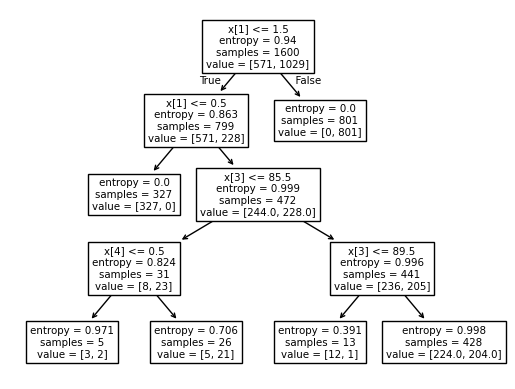

In [20]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plot_tree(RecommendationTree)
plt.show()